# Phân tích Khám phá Dữ liệu (EDA) & Khai phá Insight - Dự án Zomato 

**Mục tiêu của Notebook này:**
Notebook này nhằm mục đích "thấu hiểu" bộ dữ liệu Zomato sau khi đã làm sạch. Chúng ta sẽ đi từ việc nắm bắt các đặc điểm cơ bản của từng biến số (Phần 1), đến việc tìm ra mối quan hệ ẩn giấu giữa các biến (Phần 2), và cuối cùng là sử dụng các kiểm định thống kê để chứng minh các giả thuyết một cách khoa học (Phần 3).

---
## Khởi tạo Môi trường & Nạp Dữ liệu

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd           
import numpy as np             
import matplotlib.pyplot as plt 
import seaborn as sns          
import scipy.stats as stats    
import warnings
from src.data.load_data import load_raw_data
from src.data.clean_data import clean_basic
from src.features.build_features import get_da_data,get_ds_data                 

In [3]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline

In [10]:
df = load_raw_data()
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [12]:
df_clean = get_da_data(df)
df_clean.head(5)


--- DA Feature Engineering 
 Cleaning data
Clean hoàn tất, kích thước dữ liệu hiện tại: (9551, 21)
Hoàn tất xử lí dữ liệu DA. Kích thước: (9551, 18)


,Restaurant Name,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.4,Green,Very Good,270,Phillipines
3,Ooma,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,Sambo Kojin,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


---
## Phần 1: Thống kê mô tả tổng quan (Univariate Analysis)
**Mục tiêu:** Hiểu rõ hình hài, sự phân bố và các đặc trưng thống kê cơ bản của từng biến độc lập trong bộ dữ liệu Zomato.

### 1.1 Phân bố của Điểm đánh giá (Aggregate Rating) & Lượt bình chọn (Votes)
**Câu hỏi phân tích:**
- Phần lớn các nhà hàng trên Zomato nhận được mức điểm đánh giá nào? Dữ liệu có bị lệch (skewed) về một phía không?
- Tỷ lệ nhà hàng chưa được đánh giá (Rating = 0.0) chiếm bao nhiêu phần trăm?
- Lượng Votes phân bố ra sao? Liệu có phải chỉ một số ít nhà hàng chiếm đại đa số lượt bình chọn?


--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---
Tổng số nhà hàng: 9551
Số nhà hàng CHƯA được đánh giá (Rating = 0.0): 2148 (Chiếm 22.49%)
Số nhà hàng ĐÃ được đánh giá: 7403

-> Điểm trung bình thực tế (Mean): 3.44
-> Điểm trung vị thực tế (Median): 3.40


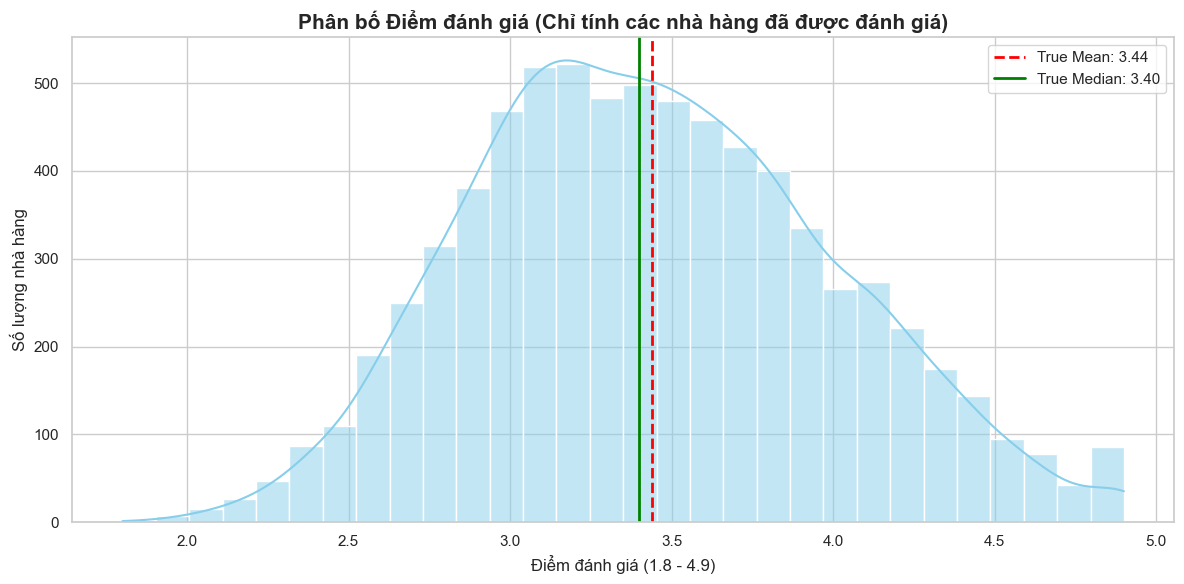

In [19]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# 1. TÁCH DỮ LIỆU ĐỂ TÍNH TOÁN CHÍNH XÁC
df_rated = df_clean[df_clean['Aggregate rating'] > 0]
unrated_count = len(df_clean[df_clean['Aggregate rating'] == 0.0])
total_restaurants = len(df_clean)

print(f"--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---")
print(f"Tổng số nhà hàng: {total_restaurants}")
print(f"Số nhà hàng CHƯA được đánh giá (Rating = 0.0): {unrated_count} (Chiếm {(unrated_count/total_restaurants)*100:.2f}%)")
print(f"Số nhà hàng ĐÃ được đánh giá: {len(df_rated)}\n")

# Tính Mean và Median thực sự (Chỉ trên tập đã đánh giá)
true_mean = df_rated['Aggregate rating'].mean()
true_median = df_rated['Aggregate rating'].median()

print(f"-> Điểm trung bình thực tế (Mean): {true_mean:.2f}")
print(f"-> Điểm trung vị thực tế (Median): {true_median:.2f}")

# 2. VẼ BIỂU ĐỒ TRÊN TẬP ĐÃ ĐÁNH GIÁ
plt.figure(figsize=(12, 6))
sns.histplot(data=df_rated, x='Aggregate rating', bins=30, kde=True, color='skyblue')

# Thêm đường trung bình và trung vị thực sự
plt.axvline(true_mean, color='red', linestyle='--', linewidth=2, label=f'True Mean: {true_mean:.2f}')
plt.axvline(true_median, color='green', linestyle='-', linewidth=2, label=f'True Median: {true_median:.2f}')

plt.title('Phân bố Điểm đánh giá (Chỉ tính các nhà hàng đã được đánh giá)', fontsize=15, fontweight='bold')
plt.xlabel('Điểm đánh giá (1.8 - 4.9)', fontsize=12)
plt.ylabel('Số lượng nhà hàng', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---
95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: 699 lượt.
Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới 49.10% tổng số lượt bình chọn trên toàn hệ thống!



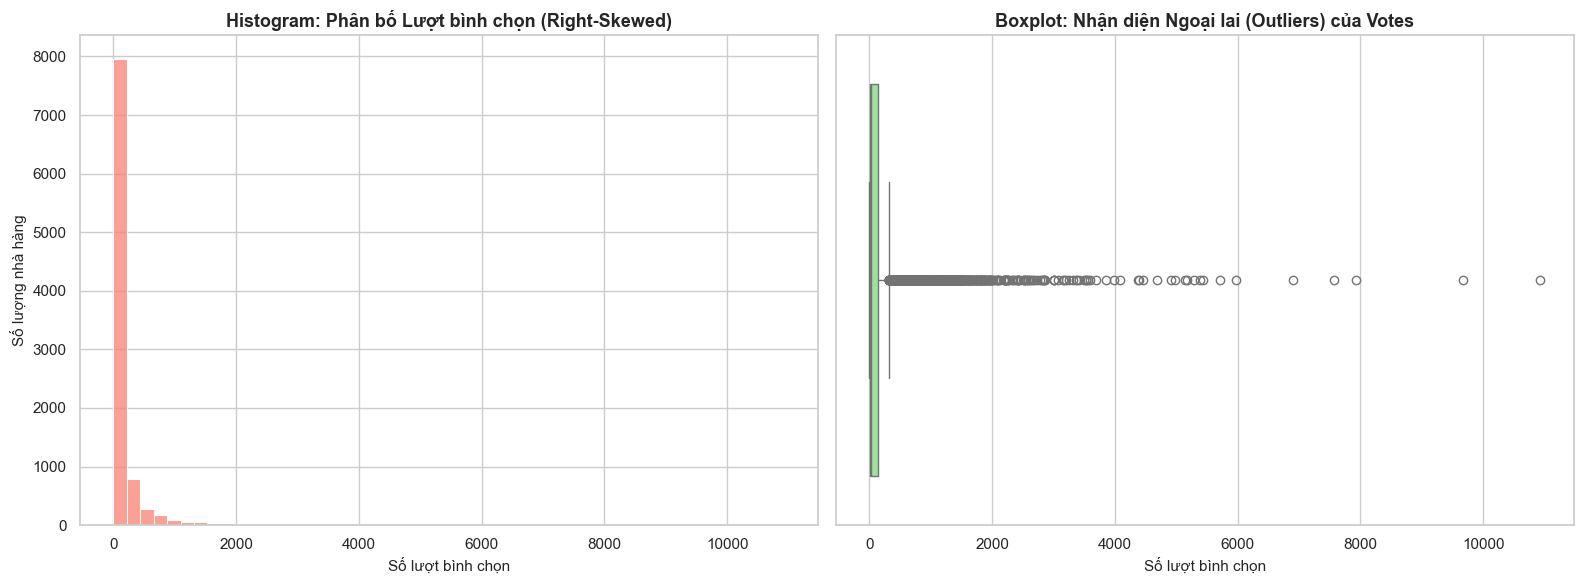

In [18]:
# 1. TÍNH TOÁN THỐNG KÊ CHO VOTES
total_votes = df_clean['Votes'].sum()
# Tìm ngưỡng Votes của Top 5% nhà hàng nhiều votes nhất
top_5_percentile_threshold = df_clean['Votes'].quantile(0.95)

# Tính tổng số votes của nhóm Top 5% này
votes_of_top_5_pct = df_clean[df_clean['Votes'] >= top_5_percentile_threshold]['Votes'].sum()
concentration_pct = (votes_of_top_5_pct / total_votes) * 100

print(f"--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---")
print(f"95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: {top_5_percentile_threshold:.0f} lượt.")
print(f"Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới {concentration_pct:.2f}% tổng số lượt bình chọn trên toàn hệ thống!\n")

# 2. VẼ BIỂU ĐỒ PHÂN BỐ VOTES (Sử dụng 2 đồ thị song song)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Histogram (KDE)
sns.histplot(data=df_clean, x='Votes', bins=50, color='salmon', ax=axes[0])
axes[0].set_title('Histogram: Phân bố Lượt bình chọn (Right-Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: Boxplot (Nhận diện Outliers)
sns.boxplot(data=df_clean, x='Votes', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot: Nhận diện Ngoại lai (Outliers) của Votes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượt bình chọn', fontsize=11)

plt.tight_layout()
plt.show()

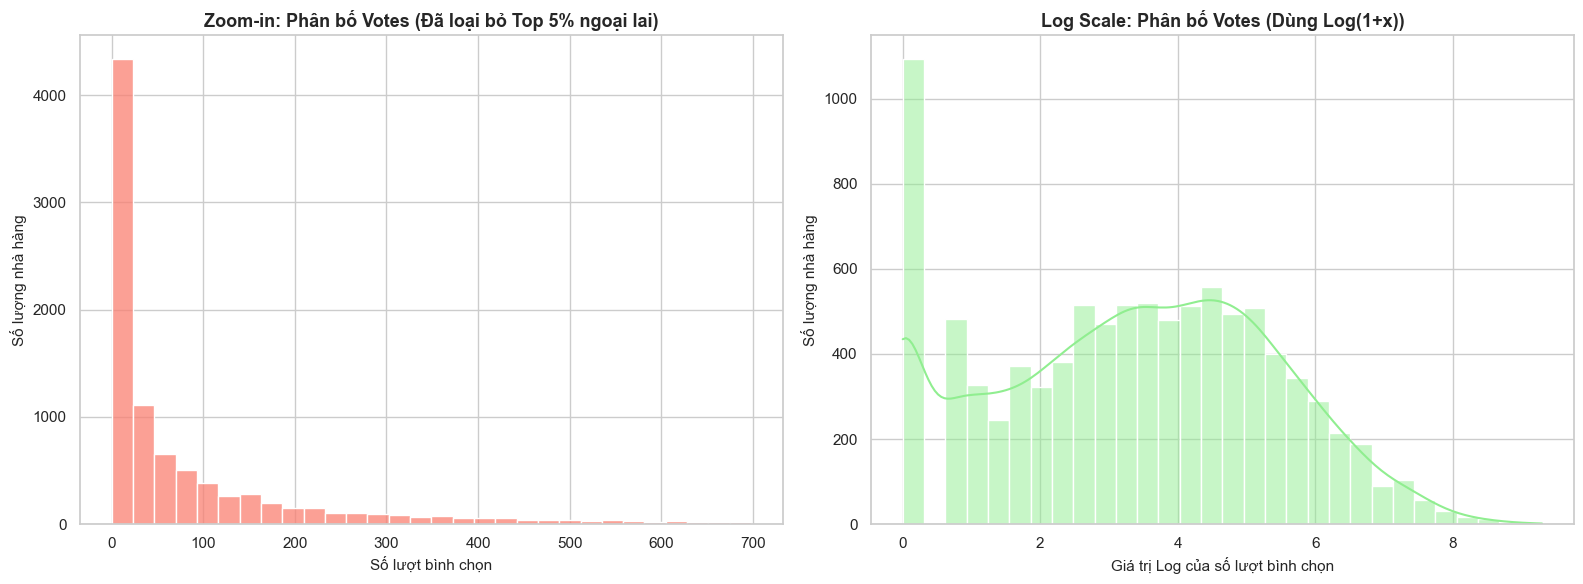

In [20]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: ZOOM IN (Chỉ lấy 95% nhà hàng bình thường)
# Dùng top_5_percentile_threshold đã tính ở ô trước
sns.histplot(data=df_clean[df_clean['Votes'] < top_5_percentile_threshold], 
             x='Votes', bins=30, color='salmon', ax=axes[0])
axes[0].set_title('Zoom-in: Phân bố Votes (Đã loại bỏ Top 5% ngoại lai)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: LOG TRANSFORMATION (Nhìn toàn cảnh bằng lăng kính Logarit)
# Tạo một cột tạm thời chuyển đổi Votes sang Log1p
log_votes = np.log1p(df_clean['Votes'])
sns.histplot(x=log_votes, bins=30, color='lightgreen', kde=True, ax=axes[1])
axes[1].set_title('Log Scale: Phân bố Votes (Dùng Log(1+x))', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá trị Log của số lượt bình chọn', fontsize=11)
axes[1].set_ylabel('Số lượng nhà hàng', fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Điểm đánh giá (Rating): Dữ liệu bị phân hóa thành 2 nhóm rõ rệt. Một lượng rất lớn nhà hàng chiếm hơn 20% (bạn xem số liệu in ra cụ thể để điền vào) hoàn toàn chưa có lượt đánh giá nào (Rating = 0.0). Đối với các nhà hàng đã được đánh giá, điểm số phân bố theo dạng xấp xỉ phân phối chuẩn (Normal Distribution), lệch nhẹ về bên trái (Left-skewed) với đỉnh tập trung ở dải điểm từ 3.0 đến 4.0.

2. Về Lượt bình chọn (Votes): Dữ liệu phân bố cực kỳ lệch phải (Right-skewed). Đa số các nhà hàng có rất ít lượt bình chọn (tập trung ở mức gần 0). Biểu đồ Boxplot cho thấy vô số các điểm ngoại lai (outliers) kéo dài về phía bên phải.

3. Tính tập trung: Số liệu chứng minh quy luật Pareto (Quy luật 80/20) tồn tại mạnh mẽ: Chỉ một nhóm cực nhỏ (Top 5% nhà hàng) đã thâu tóm phần lớn lượng tương tác của toàn bộ nền tảng Zomato.

### 1.2 Phân tích Chi phí trung bình (Average Cost for two) & Phân khúc giá (Price range)
**Câu hỏi phân tích:**
- Mức giá trung bình cho 2 người ăn thường rơi vào khoảng nào? Có xuất hiện các giá trị ngoại lệ (outliers - nhà hàng quá xa xỉ) không?
- Tỷ trọng các nhà hàng thuộc các phân khúc giá (Price range 1 đến 4) phân bổ như thế nào? Zomato chủ yếu phục vụ khách hàng bình dân hay cao cấp?


--- THỐNG KÊ CHI PHÍ CHO 2 NGƯỜI (RAW DATA) ---
Mức giá trung vị (Median): 400
95% các nhà hàng có mức giá thấp hơn hoặc bằng: 1700



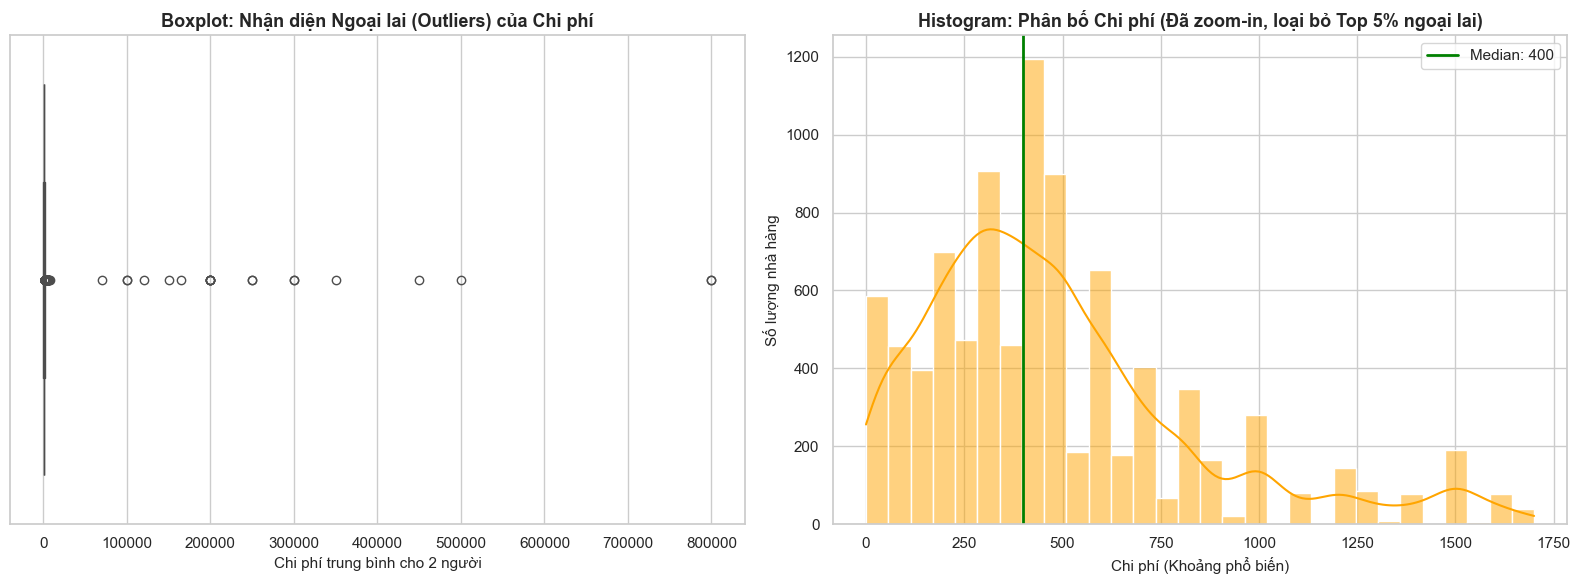

In [21]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# 1. TÍNH TOÁN THỐNG KÊ CHI PHÍ TRUNG BÌNH
# Tính phân vị thứ 95 để tìm ra ngưỡng loại bỏ các outliers cực đoan (thường do khác tiền tệ)
cost_95th_percentile = df_clean['Average Cost for two'].quantile(0.95)
median_cost = df_clean['Average Cost for two'].median()

print(f"--- THỐNG KÊ CHI PHÍ CHO 2 NGƯỜI (RAW DATA) ---")
print(f"Mức giá trung vị (Median): {median_cost:.0f}")
print(f"95% các nhà hàng có mức giá thấp hơn hoặc bằng: {cost_95th_percentile:.0f}\n")

# 2. VẼ BIỂU ĐỒ PHÂN BỐ CHI PHÍ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Boxplot nhìn toàn cảnh Outliers
sns.boxplot(data=df_clean, x='Average Cost for two', color='gold', ax=axes[0])
axes[0].set_title('Boxplot: Nhận diện Ngoại lai (Outliers) của Chi phí', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chi phí trung bình cho 2 người', fontsize=11)

# Đồ thị 2: Histogram Zoom-in (Chỉ lấy 95% dữ liệu phổ biến)
df_zoomed_cost = df_clean[df_clean['Average Cost for two'] <= cost_95th_percentile]
sns.histplot(data=df_zoomed_cost, x='Average Cost for two', bins=30, kde=True, color='orange', ax=axes[1])
axes[1].axvline(median_cost, color='green', linestyle='-', linewidth=2, label=f'Median: {median_cost:.0f}')

axes[1].set_title('Histogram: Phân bố Chi phí (Đã zoom-in, loại bỏ Top 5% ngoại lai)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chi phí (Khoảng phổ biến)', fontsize=11)
axes[1].set_ylabel('Số lượng nhà hàng', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

--- THỐNG KÊ PHÂN KHÚC GIÁ ---
Phân khúc 1: 4444 nhà hàng (46.53%)
Phân khúc 2: 3113 nhà hàng (32.59%)
Phân khúc 3: 1408 nhà hàng (14.74%)
Phân khúc 4: 586 nhà hàng (6.14%)



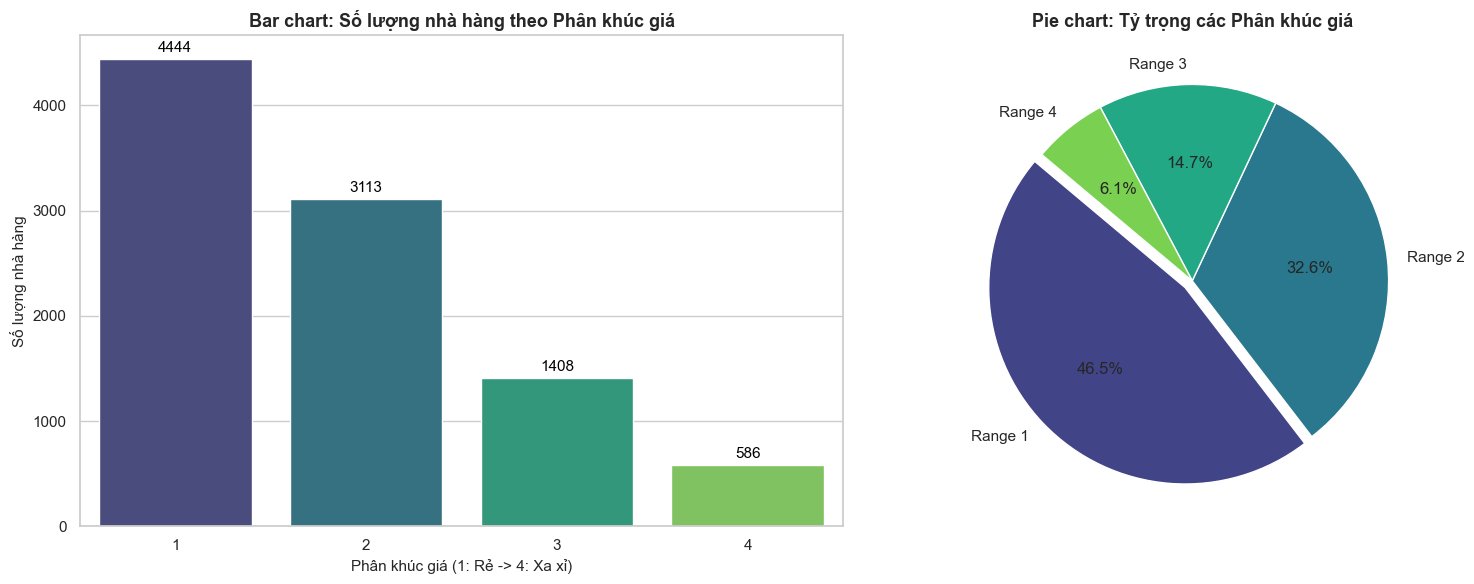

In [22]:
# 1. TÍNH TOÁN TỶ TRỌNG PHÂN KHÚC GIÁ
price_counts = df_clean['Price range'].value_counts().sort_index()
price_pct = (price_counts / len(df_clean)) * 100

print(f"--- THỐNG KÊ PHÂN KHÚC GIÁ ---")
for pr, count, pct in zip(price_counts.index, price_counts.values, price_pct.values):
    print(f"Phân khúc {pr}: {count} nhà hàng ({pct:.2f}%)")
print()

# 2. VẼ BIỂU ĐỒ THỂ HIỆN TỶ TRỌNG
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Barplot (Countplot) đếm số lượng
sns.countplot(data=df_clean, x='Price range', palette='viridis', ax=axes[0], 
              order=[1, 2, 3, 4])
axes[0].set_title('Bar chart: Số lượng nhà hàng theo Phân khúc giá', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Phân khúc giá (1: Rẻ -> 4: Xa xỉ)', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Thêm số liệu lên đầu các cột
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), 
                     textcoords='offset points')

# Đồ thị 2: Pie chart thể hiện Tỷ lệ phần trăm
explode = (0.05, 0, 0, 0) # Nhấn mạnh phân khúc 1
axes[1].pie(price_counts, labels=[f"Range {i}" for i in price_counts.index], 
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 4), explode=explode)
axes[1].set_title('Pie chart: Tỷ trọng các Phân khúc giá', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Chi phí trung bình (Average Cost): Biểu đồ Boxplot xuất hiện các giá trị cực kỳ lớn (outliers) kéo dài trục X. Lưu ý chuyên môn: Sự lệch lạc này một phần do sự chênh lệch đơn vị tiền tệ giữa các quốc gia chưa được quy đổi (ví dụ IDR của Indonesia vs USD của Mỹ). Tuy nhiên, khi "Zoom-in" vào 95% dữ liệu phổ biến, ta thấy mức chi phí tập trung dồn dập ở bên trái (mức giá thấp).

2. Về Phân khúc giá (Price Range): Biểu đồ Bar chart và Pie chart chứng minh rõ ràng chiến lược định vị của Zomato:

    * Nền tảng này chủ yếu phục vụ tệp khách hàng bình dân. Phân khúc giá 1 (Giá rẻ) chiếm tỷ trọng lớn nhất (khoảng ~46.5% - bạn check số thực tế ở code để sửa lại nếu cần).

    * Cộng dồn Phân khúc 1 và Phân khúc 2, Zomato có gần 80% nhà hàng thuộc mức giá trung bình - thấp.

    * Các nhà hàng xa xỉ (Phân khúc 3 và 4) chỉ chiếm một phần nhỏ (khoảng 20%), đóng vai trò làm phong phú hệ sinh thái chứ không phải mảng kinh doanh cốt lõi (Volume driver).

### 1.3 Mức độ phủ sóng của Dịch vụ (Table Booking & Online Delivery)
**Câu hỏi phân tích:**
- Bao nhiêu phần trăm nhà hàng trên nền tảng cho phép đặt bàn trước (Has Table booking)?
- Dịch vụ giao hàng trực tuyến (Has Online delivery) có phổ biến không? Tỷ lệ chấp nhận dịch vụ này là bao nhiêu?

--- THỐNG KÊ DỊCH VỤ NHÀ HÀNG ---
1. Đặt bàn trước (Table Booking):
   - Có (Yes): 1158 (12.12%)
   - Không (No): 8393 (87.88%)

2. Giao hàng trực tuyến (Online Delivery):
   - Có (Yes): 2451 (25.66%)
   - Không (No): 7100 (74.34%)



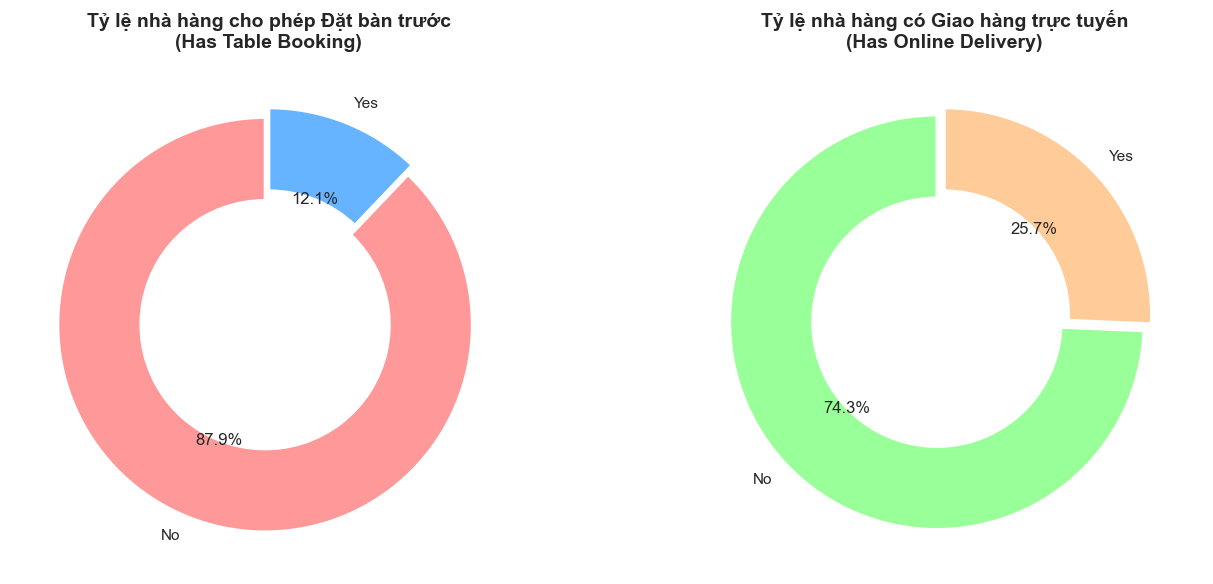

In [23]:
# 1. TÍNH TOÁN SỐ LIỆU THỐNG KÊ
table_booking_counts = df_clean['Has Table booking'].value_counts()
online_delivery_counts = df_clean['Has Online delivery'].value_counts()

total_restaurants = len(df_clean)

print("--- THỐNG KÊ DỊCH VỤ NHÀ HÀNG ---")
print(f"1. Đặt bàn trước (Table Booking):")
print(f"   - Có (Yes): {table_booking_counts.get('Yes', 0)} ({table_booking_counts.get('Yes', 0)/total_restaurants*100:.2f}%)")
print(f"   - Không (No): {table_booking_counts.get('No', 0)} ({table_booking_counts.get('No', 0)/total_restaurants*100:.2f}%)\n")

print(f"2. Giao hàng trực tuyến (Online Delivery):")
print(f"   - Có (Yes): {online_delivery_counts.get('Yes', 0)} ({online_delivery_counts.get('Yes', 0)/total_restaurants*100:.2f}%)")
print(f"   - Không (No): {online_delivery_counts.get('No', 0)} ({online_delivery_counts.get('No', 0)/total_restaurants*100:.2f}%)\n")

# 2. VẼ BIỂU ĐỒ DONUT CHART
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cài đặt chung cho Donut chart
wedgeprops = {'width': 0.4, 'edgecolor': 'w', 'linewidth': 2} # Tạo lỗ hổng ở giữa (width) và viền trắng

# Đồ thị 1: Table Booking
colors_booking = ['#ff9999', '#66b3ff']
axes[0].pie(table_booking_counts, labels=table_booking_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_booking, wedgeprops=wedgeprops, explode=(0.05, 0))
axes[0].set_title('Tỷ lệ nhà hàng cho phép Đặt bàn trước\n(Has Table Booking)', fontsize=14, fontweight='bold')

# Đồ thị 2: Online Delivery
colors_delivery = ['#99ff99', '#ffcc99']
axes[1].pie(online_delivery_counts, labels=online_delivery_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_delivery, wedgeprops=wedgeprops, explode=(0.05, 0))
axes[1].set_title('Tỷ lệ nhà hàng có Giao hàng trực tuyến\n(Has Online Delivery)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Dịch vụ Đặt bàn trước (Table Booking): Mức độ phủ sóng rất thấp. Đại đa số các nhà hàng trên Zomato (khoảng hơn 80%) không cung cấp dịch vụ đặt bàn. Điều này hoàn toàn logic vì (như đã phân tích ở phần trước) nền tảng này tập trung mạnh vào phân khúc giá bình dân/thấp – nơi khách hàng thường đến ăn trực tiếp kiểu "walk-in" hoặc mua mang đi thay vì cần lên lịch trình đặt bàn trang trọng.

2. Dịch vụ Giao hàng trực tuyến (Online Delivery): Phổ biến hơn so với đặt bàn, tuy nhiên tỷ lệ nhà hàng không có giao hàng online vẫn chiếm ưu thế (hơn 70%). Điều này mở ra một câu hỏi chiến lược lớn: Liệu những nhà hàng chịu khó tích hợp Giao hàng Online có nhận được lượng Votes cao hơn và Điểm đánh giá tốt hơn không?

### 1.4 Khám phá Yếu tố Địa lý & Ẩm thực (Country, City & Cuisines)
**Câu hỏi phân tích:**
- Top 10 thành phố hoặc quốc gia có số lượng nhà hàng đăng ký trên Zomato lớn nhất là gì?
- Top 10 loại hình ẩm thực (Cuisines) được kinh doanh nhiều nhất?


--- TOP 5 QUỐC GIA CÓ NHIỀU NHÀ HÀNG NHẤT ---
- India: 8652 nhà hàng (90.59%)
- United States: 434 nhà hàng (4.54%)
- United Kingdom: 80 nhà hàng (0.84%)
- Brazil: 60 nhà hàng (0.63%)
- UAE: 60 nhà hàng (0.63%)




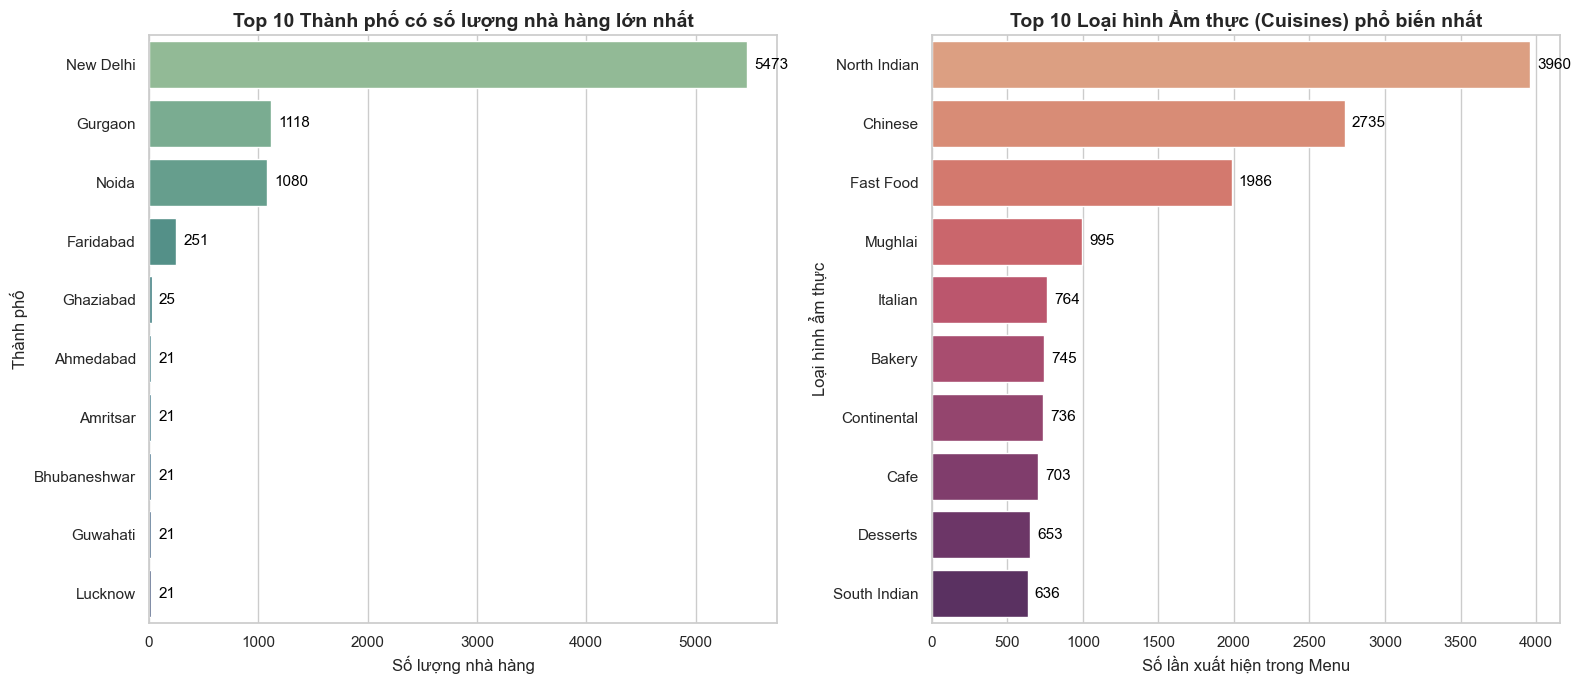

In [29]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. TÍNH TOÁN & XỬ LÝ DỮ LIỆU
# ==========================================

# 1.1 Thống kê Top Quốc gia
top_countries = df_clean['Country'].value_counts().head(5)

print("--- TOP 5 QUỐC GIA CÓ NHIỀU NHÀ HÀNG NHẤT ---")
for country, count in top_countries.items():
    pct = (count / len(df_clean)) * 100
    print(f"- {country}: {count} nhà hàng ({pct:.2f}%)")
print("\n")

# 1.2 Lấy Top 10 Thành phố
top_cities = df_clean['City'].value_counts().head(10)

# 1.3 Xử lý cột Cuisines (Tách các món ăn trong cùng 1 nhà hàng)
# Ví dụ: "North Indian, Chinese" -> Tách thành 2 dòng "North Indian" và "Chinese"
cuisines_exploded = df_clean['Cuisines'].dropna().str.split(', ').explode()
top_cuisines = cuisines_exploded.value_counts().head(10)

# ==========================================
# 2. VẼ BIỂU ĐỒ BAR CHART NẰM NGANG
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Đồ thị 1: Top 10 Thành phố
sns.barplot(x=top_cities.values, y=top_cities.index, palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Thành phố có số lượng nhà hàng lớn nhất', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng nhà hàng', fontsize=12)
axes[0].set_ylabel('Thành phố', fontsize=12)

# Thêm nhãn số liệu vào cuối mỗi cột cho biểu đồ Thành phố
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), 
                     textcoords='offset points')

# Đồ thị 2: Top 10 Loại hình ẩm thực (Cuisines)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='flare', ax=axes[1])
axes[1].set_title('Top 10 Loại hình Ẩm thực (Cuisines) phổ biến nhất', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lần xuất hiện trong Menu', fontsize=12)
axes[1].set_ylabel('Loại hình ẩm thực', fontsize=12)

# Thêm nhãn số liệu vào cuối mỗi cột cho biểu đồ Ẩm thực
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Địa lý (Quốc gia & Thành phố): Bộ dữ liệu này bị lệch cực kỳ nặng về phía thị trường Ấn Độ (India). Ấn Độ chiếm tỷ trọng áp đảo (thường >90% - bạn check số in ra ở console để điền chính xác). Đặc biệt, khi nhìn vào Top 10 thành phố, ta sẽ thấy sự thống trị hoàn toàn của khu vực Vùng thủ đô quốc gia (NCR) của Ấn Độ bao gồm New Delhi, Gurgaon, và Noida.
=> Hệ quả phân tích: Bất kỳ kết luận trung bình nào trên toàn tập dữ liệu này thực chất là phản ánh thị trường Ấn Độ, chứ không mang tính đại diện cho toàn cầu.

2. Về Loại hình Ẩm thực (Cuisines): Hoàn toàn logic với Insight địa lý ở trên. Do hầu hết nhà hàng nằm ở Bắc Ấn, nên "North Indian" chính là loại ẩm thực xuất hiện nhiều nhất với số lượng áp đảo. Tiếp theo sau là các loại đồ ăn mang tính tiện lợi, phục vụ số đông như Chinese (Món Hoa), Fast Food (Đồ ăn nhanh), và Mughlai.

---
## Phần 2: Phân tích tương quan đa biến (Bivariate & Multivariate Analysis)
**Mục tiêu:** Khám phá sự tương tác giữa 2 hoặc nhiều biến số để tìm ra những "câu chuyện" thú vị (Insights) đằng sau dữ liệu.

### 2.1 Mối liên hệ giữa Giá cả và Chất lượng (Cost/Price Range vs. Rating/Votes)
**Câu hỏi phân tích:**
- Có phải nhà hàng càng đắt tiền (Price range cao / Average Cost cao) thì điểm đánh giá (Aggregate rating) càng tốt không?
- Phân khúc giá nào thu hút được lượng tương tác (Votes) lớn nhất từ người dùng?

*(Code vẽ Scatter plot, Boxplot nhóm theo Price Range, và Heatmap tương quan ở dưới)*

### 2.2 Tác động của Dịch vụ tiện ích đến Trải nghiệm khách hàng
**Câu hỏi phân tích:**
- Những nhà hàng có cung cấp Giao hàng trực tuyến (Online delivery) có điểm đánh giá trung bình cao hơn những nơi không cung cấp dịch vụ này không?
- Liệu việc cho phép Đặt bàn trước (Table booking) có giúp nhà hàng nhận được lượng Votes khổng lồ hơn không? (Đặc biệt ở các phân khúc giá cao).

*(Code vẽ Violin plot hoặc Grouped Bar chart ở dưới)*

### 2.3 Phân tích Không gian (Geospatial Analysis)
**Câu hỏi phân tích:**
- Dựa trên Vĩ độ (Latitude) và Kinh độ (Longitude), các nhà hàng có điểm đánh giá "Excellent" hoặc phân khúc giá đắt đỏ thường tập trung ở những khu vực địa lý nào?

*(Code vẽ Scatter map hoặc sử dụng thư viện Folium/Plotly để rải điểm lên bản đồ ở dưới)*

---
## Phần 3: Kiểm định giả thuyết thống kê (Hypothesis Testing)
**Mục tiêu:** Sử dụng toán học để chứng minh các nhận định rút ra từ phần EDA không phải là do ngẫu nhiên, mà có ý nghĩa thống kê thực sự (Statistical Significance). Mức ý nghĩa (Alpha) chọn là 0.05.

### 3.1 Giả thuyết 1: Tác động của Giao hàng trực tuyến đến Điểm đánh giá
- **$H_0$ (Giả thuyết không):** Không có sự khác biệt về trung bình điểm đánh giá (Aggregate rating) giữa nhóm nhà hàng có giao hàng trực tuyến và nhóm không có.
- **$H_1$ (Giả thuyết thay thế):** Trung bình điểm đánh giá của nhà hàng CÓ giao hàng trực tuyến cao hơn (hoặc khác biệt có ý nghĩa) so với nhóm KHÔNG CÓ.
- **Phương pháp:** Independent Two-sample T-test (hoặc Mann-Whitney U test nếu dữ liệu không phân phối chuẩn).

*(Code thực hiện test thống kê và in kết luận P-value ở dưới)*

### 3.2 Giả thuyết 2: Chi phí ăn uống tại các nhà hàng cho phép Đặt bàn trước
- **$H_0$:** Chi phí trung bình cho 2 người (Average Cost for two) của nhà hàng cho phép đặt bàn và không cho phép đặt bàn là như nhau.
- **$H_1$:** Chi phí trung bình cho 2 người của nhà hàng CÓ cho phép đặt bàn cao hơn đáng kể.
- **Phương pháp:** Independent Two-sample T-test.

*(Code thực hiện test thống kê và in kết luận P-value ở dưới)*

### 3.3 Giả thuyết 3: Mối liên hệ giữa Phân khúc giá và Quyết định cung cấp dịch vụ giao hàng
- **$H_0$:** Phân khúc giá (Price range) và việc cung cấp dịch vụ giao hàng trực tuyến (Has Online delivery) là hai yếu tố độc lập, không liên quan đến nhau.
- **$H_1$:** Có mối quan hệ phụ thuộc giữa phân khúc giá của nhà hàng và việc họ có cung cấp giao hàng trực tuyến hay không (vd: nhà hàng quá cao cấp ít giao hàng hơn).
- **Phương pháp:** Chi-Square Test of Independence (Kiểm định Chi-bình phương).

*(Code tính toán bảng chéo Crosstab, thực hiện Chi-square test và in kết luận ở dưới)*

---
## TỔNG KẾT & INSIGHTS HÀNH ĐỘNG 🚀
*(Viết vào đây 3-5 gạch đầu dòng tóm tắt những phát hiện quan trọng nhất từ cả 3 phần trên. Ví dụ: Khuyến nghị cho Zomato nên tập trung push dịch vụ Delivery cho phân khúc giá nào, hoặc insight về hành vi đánh giá của người dùng...)*